Problem definition:

- Sử dụng KNN Classifier và  TF-IDF để tạo một model dự đoán email rác (Spam) hay email thật (Ham), tuỳ thuộc vào các đặc điểm:
    - Nội dung văn bản của email (cột text)
    - Tần suất xuất hiện của các từ khoá cụ thể trong email.

Nhận xét dữ liệu trong spam_ham_dataset.csv:
- Dữ liệu có đủ 5171 dòng, 4 features (label, text, label_num) (cột đầu không có tên), chứa các loại thông tin như interger, và text/phân loại(0,1)
- Chất lượng thông tin:
    - Accuracy: Thông tin chuẩn và không bị nhập nhầm. Cột label chứa 2 giá trị phân loại spam và ham, và có giá trị tương tự với lần lượt số 1(spam), và 0(ham) ở bên cột label_num. Cột text luôn bắt đầu bằng tiêu đề thư: "Subject: "
    - Completeness: Dữ liệu đầy đủ. Tất cả 5171 dòng đều có đủ giá trị cho cả 4 features, và không có dữ liệu bị thiếu.
    - Consistency: Giá trị của các features đồng bộ, đều viết là spam/ham chứ không viết nhầm, và cột text cũng chung cấu trúc Tiêu đề -> Nooij dung
    - Relevance: Cột text (nội dung email) có liên quan trực tiếp tới việc email có phải là spam hay ham. Trong đó label viết chữ spam/ham, và label_num chứa giá trị 1/0 để mô hình sử dụng. Cái cột không có tên ở đầu phải bị drop vì không có giá trị.
    - Timeliness: File không có ghi trực tiếp thời gian nhưng ở nội dung của một số email chứa các năm như 2000, 2001, nên các email khá cũ.


Tương tự như Regressor, mình import các thư viện để sử dụng.

- Điểm khác biệt là giờ sẽ sử dụng TfidVectorizer để chuyển các từ trong email thành một giá trị số. Điều này là bởi vì để KNN tính được khoảng cách giữa các email với nhau, nó cần các con số chứ không phải số.

- Accuracy_score là để tính tỷ lệ dự đoán đúng: Số lượng dự đoán đúng/ Tổng số lượng dữ liệu.

- Do accuracy_score chỉ cho mình biết được đúng sai, confusion_matrix sẽ chỉ rõ đúng/sai như thế nào:
    - True Positive (TP): đoán là Spam, thực tế đúng là Spam (Dự đoán đúng).

    - True Negative (TN): đoán là Ham, thực tế cũng là Ham (Dự đoán đúng).

    - False Positive (FP): đoán là Spam, nhưng thực tế lại là Ham (Báo động giả).

    - False Negative (FN): đoán là Ham, nhưng thực tế là Spam (Bỏ sót thư rác).



In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

Giờ sẽ phân loại dữ liệu và lấy ra X và y.
Ta sẽ drop cột đầu tiên không cần thiết (số thứ tự index).

X sẽ là cột text chứa nội dung th
y sẽ là cột label_num chứa nhãn 0 và 1, không cần lấy label xong rồi one-hot encode nữa.

In [41]:
df = pd.read_csv('spam_ham_dataset.csv')
X = df['text']
y = df['label_num']


Giống bên regressor mình sẽ chia dữ liệu thành 2 bên, một bên để train, bên còn lại để test. Mình phải chia tệp trước xong rồi hẵng dùng Tfidvectorizer, bởi mình sẽ chỉ train nó theo nội dung của 80% email bên train, 20% còn lại để test.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=67)

sKhi chia xong mình sẽ biến các text thành con số, sử dụng TfidfVectorizer. Hàm sẽ hoạt động theo cách:

1. Chấm điểm Term Frequency - đếm xem một từ xuất hiện bao nhiều lần trong email đó:
TF = Số lần từ xuất hiện trong email / Tổng số từ trong email

2. Chấm điểm Inverse Document Frequency - độ hiếm trên toàn bộ dữ liệu(đếm xem một từ xuất hiện trong bao nhiêu email trên tổng số)

IDF = log(tổng số email/số email chứa từ khoá)
--> Những từ cơ bản trong ngữ pháp tiếng anh như "is", "the", "and" (ở dưới là "stop_words")gần như email nào cũng xuất hiện -> mẫu số lớn, hàm log sẽ tính điểm các từ này xuống gần 0. Còn các từ chỉ xuất hiện ở một số email nhất định sẽ có điểm cao.

3. Tính kết quả TF x IDF
Đây sẽ là con số để KNN sử dụng để tính khoảng các giữa các email với nhau.



In [43]:
tfidf = TfidfVectorizer(max_features=4000,stop_words='english')
X_train_vector = tfidf.fit_transform(X_train)
X_test_vector  = tfidf.transform(X_test)

Sau khi đã thay đổi xong X_train và dùng dữ liệu của X_train để thay đổi X_test, ta sẽ dùng KNN, đầu tiên với số Neighbors = 5, và train.

In [44]:
knn = KNeighborsClassifier(n_neighbors=5,weights="distance",metric="euclidean")
knn.fit(X_train_vector,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Sau đó dùng model đã được train và predict với X_test_vector.
Tính toạn độ chính xác tổng thể và Confusion matrix

In [45]:
y_predict = knn.predict(X_test_vector)
acc = accuracy_score(y_true=y_test, y_pred=y_predict)
conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_predict)

print(f"Accuracy Score {acc*100}")
print(f"ConfusionMatrix:")
print("Đọc theo kiểu:")
print("TN   FP")
print("FN   TP")
print(conf_matrix)


Accuracy Score 96.90821256038647
ConfusionMatrix:
Đọc theo kiểu:
TN   FP
FN   TP
[[712  13]
 [ 19 291]]


In [46]:
k_values  = range(1,51)
acc_log = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k,weights="distance",metric="euclidean")
    knn.fit(X_train_vector,y_train)
    y_predict = knn.predict(X_test_vector)
    temp_acc = accuracy_score(y_true=y_test, y_pred=y_predict)
    temp_acc_percent = round(temp_acc * 100, 2)
    acc_log.append(temp_acc_percent)



Giờ sẽ dùng pyplot để vẽ ra biều đồ để minh hoạ sự khác biệt về accuracy giữa số neighbors với nhau.

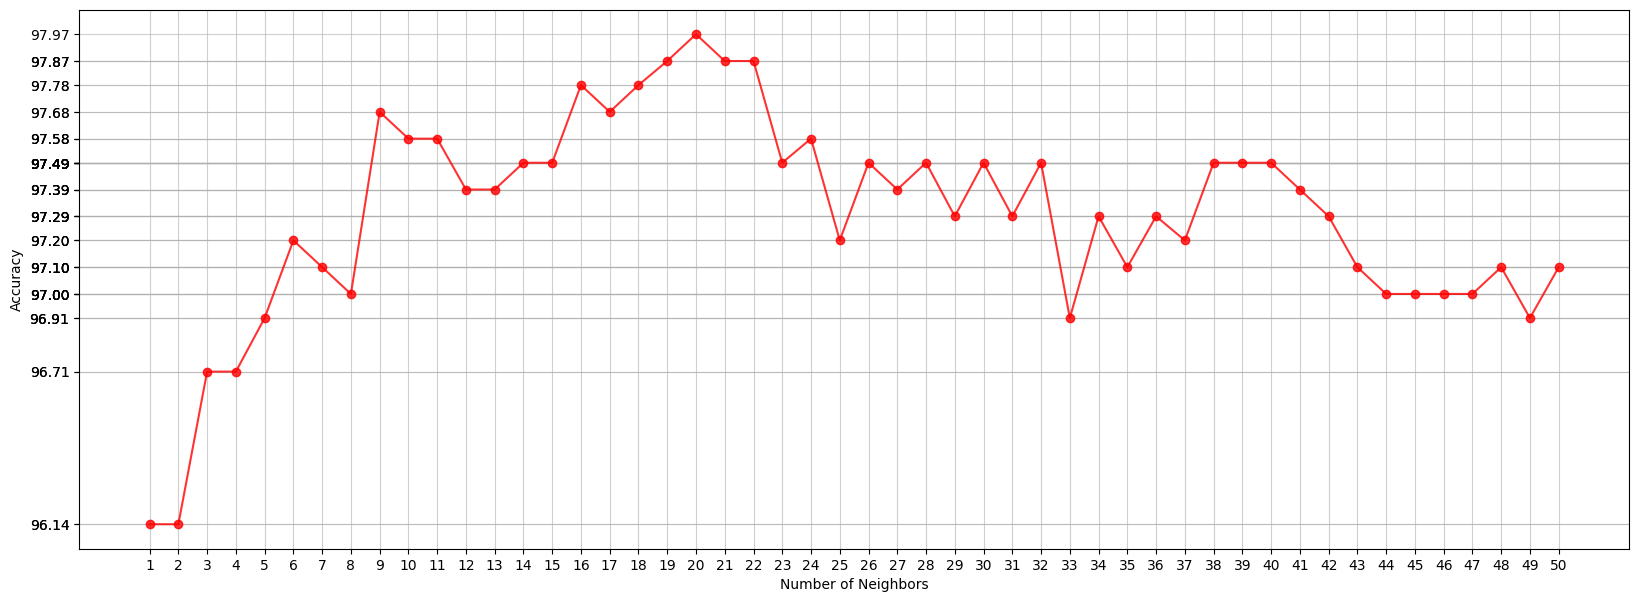

In [47]:
plt.figure(figsize=(20,7))
plt.plot(k_values, acc_log, marker='o', color='red', alpha=0.8)
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.yticks(acc_log)
plt.grid(alpha=0.6)
plt.show()


Vậy từ đó mình rút ra là mô hình phân loại email spam/ham chạy tốt nhất khi mình lấy số neighbors là 17, hoặc 22, khi dự đoán phân biệt đúng 97,58% trong tổng số email.